# COMP 3610: Big Data Analytics - Assignment 3
## LLM-Powered Applications & Distributed Computing


 **Student ID:** 816040879


In [1]:
import importlib

pkgs = [
    "torch", "numpy", "pandas", "sklearn",
    "matplotlib", "seaborn", "shap", "requests", "pyarrow", "pyspark",
    "langchain", "langchain_community", "langchain_text_splitters","langchain_huggingface",
    "sentence_transformers", "transformers", "pypdf", "openai",
    "chromadb", "dotenv",
]

print("Package Versions")
print("-" * 30)
for pkg_name in pkgs:
    try:
        mod = importlib.import_module(pkg_name)
        ver = getattr(mod, "__version__", "n/a")
        print(f"  {pkg_name:<25} {ver}")
    except Exception as e:
        print(f"  {pkg_name:<25} NOT FOUND")
print("-" * 30)

Package Versions
------------------------------
  torch                     2.6.0+cu124
  numpy                     2.3.2
  pandas                    2.3.1
  sklearn                   1.8.0
  matplotlib                3.10.8
  seaborn                   0.13.2
  shap                      0.51.0
  requests                  2.33.0
  pyarrow                   18.1.0
  pyspark                   4.1.1
  langchain                 1.2.13
  langchain_community       0.4.1
  langchain_text_splitters  n/a
  langchain_huggingface     n/a
  sentence_transformers     5.3.0
  transformers              5.4.0
  pypdf                     6.9.2
  openai                    2.30.0
  chromadb                  1.5.5
  dotenv                    n/a
------------------------------


In [2]:
import requests
import os 
import time
import json

import shutil
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
from pathlib import Path

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
from pyspark.sql.window import Window

from langchain_community.document_loaders import PyPDFDirectoryLoader
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma

from langchain_text_splitters import RecursiveCharacterTextSplitter
from pypdf import PdfReader

from openai import OpenAI


TAXI_URL  = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
TAXI_PATH = "data/raw/yellow_tripdata_2024-01.parquet"

load_dotenv()

# os.environ["JAVA_HOME"]       = r"C:\Program Files\Java\jdk-17"
# os.environ["HADOOP_HOME"]     = r"C:\hadoop-3.3.6"
# os.environ["hadoop.home.dir"] = r"C:\hadoop-3.3.6"
# os.environ["PATH"]            = r"C:\Program Files\Java\jdk-17\bin" + ";" + r"C:\hadoop-3.3.6\bin" + ";" + os.environ["PATH"]

True

## Part 1: Distributed Data Processing with Spark

### Task 1.1: Spark Environment Setup & Data Loading

### `build_spark_session(app_name, driver_mem)`
Initialises a local SparkSession with AQE enabled. `driver_mem` defaults to `4g`, usefull so I can test different values. 

In [3]:
def build_spark_session(app_name: str, driver_mem: str = "4g") -> SparkSession:
    return (
        SparkSession.builder
            .master("local[*]")
            .appName(app_name)
            .config("spark.driver.memory", driver_mem)
            .config("spark.sql.adaptive.enabled", "true")
            .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
            .getOrCreate()
    )

### `download_dataset(url, dest)`
Streams the parquet file to disk in chunks. Skips the download entirely if the file already exists, so re-running the notebook won't re-download.

In [4]:
def download_dataset(url: str, dest: str) -> None:
    if Path(dest).exists():
        print(f"Already exists: {dest} ({os.path.getsize(dest)/1e6:.1f} MB)")
        return

    os.makedirs(Path(dest).parent, exist_ok=True)
    print(f"Downloading {url} ...")
    try:
        r = requests.get(url, stream=True)
        r.raise_for_status()
        with open(dest, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
        print(f"Saved to {dest} ({os.path.getsize(dest)/1e6:.1f} MB)")
    except requests.exceptions.RequestException as e:
        print(f"Download failed: {e}")

### `load_and_profile(spark, path)`
Loads the parquet into a Spark DataFrame, forces a `count()` to materialise it, then prints row count, column count, partition count and schema. Returns the DataFrame for use in the next task.

In [5]:
def load_and_profile(spark: SparkSession, path: str):
    """Load parquet, force a count to materialise, return the DataFrame."""
    df = spark.read.parquet(path)
    print(f"Rows       : {df.count():,}")
    print(f"Columns    : {len(df.columns)}")
    print(f"Partitions : {df.rdd.getNumPartitions()}")
    df.printSchema()
    return df

### `compare_load_times(spark, path)`
Times a full Spark read (schema + `count()` action) against a Pandas read of the same file and prints a comparison. Interprets the result dynamically  but on a ~50MB local file Pandas typically wins due to JVM overhead, but Spark's advantage emerges at GB+ scale across a cluster.

In [6]:
def compare_load_times(spark: SparkSession, path: str):
    t0 = time.perf_counter()
    spark.read.parquet(path).count()
    spark_t = time.perf_counter() - t0

    t0 = time.perf_counter()
    pdf = pd.read_parquet(path)
    pd_t = time.perf_counter() - t0
    mem_mb = pdf.memory_usage(deep=True).sum() / 1e6
    del pdf

    print(f"\n{'Engine':<10} {'Time (s)':>10}  Notes")
    print(f"{'Spark':<10} {spark_t:>10.3f}  includes count() action")
    print(f"{'Pandas':<10} {pd_t:>10.3f}  {mem_mb:.0f} MB loaded into RAM")

    if pd_t < spark_t:
        print(f"\nPandas was {spark_t/pd_t:.2f}x faster on this ~50MB local file.")
        print("Expected - Spark's JVM + task scheduling overhead dominates at small scale.")
        print("At GB+ scale across a real cluster, Spark's parallelism reverses this gap.")
    else:
        print(f"\nSpark was {pd_t/spark_t:.2f}x faster (warm JVM / cached filesystem).")

In [7]:
spark = build_spark_session("COMP3610_A3")
spark.sparkContext.setLogLevel("WARN")

download_dataset(TAXI_URL, TAXI_PATH)
pyspark_df = load_and_profile(spark, TAXI_PATH)
compare_load_times(spark, TAXI_PATH)

Already exists: data/raw/yellow_tripdata_2024-01.parquet (50.0 MB)
Rows       : 2,964,624
Columns    : 19
Partitions : 12
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)


En

In [8]:
print(f"Spark UI  : http://localhost:4040")
print(f"Cores     : {spark.sparkContext.defaultParallelism}")

relevant = ["memory", "core", "master"]
for key, value in sorted(spark.sparkContext.getConf().getAll()):
    if any(k in key.lower() for k in relevant):
        print(f"  {key} = {value}")

Spark UI  : http://localhost:4040
Cores     : 16
  spark.driver.memory = 4g
  spark.master = local[*]


### Task 1.2: Data Cleaning & Feature Engineering in Spark

### `clean_trip_data(df)`
Runs the DataFrame through a series of filters for null removal, distance/fare bounds, and trip direction validation. Prints a step-by-step table showing rows removed at each stage with totals.

In [9]:
def clean_trip_data(df):
    CRITICAL_COLS = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "PULocationID", "DOLocationID", "fare_amount", "trip_distance",
]
    
    n0 = df.count()
    steps = []

    df = df.dropna(subset=CRITICAL_COLS)
    steps.append(("drop critical nulls",    df.count()))

    df = df.filter(F.col("trip_distance") > 0)
    steps.append(("positive distance",      df.count()))

    df = df.filter(F.col("fare_amount") > 0)
    steps.append(("positive fare",          df.count()))

    df = df.filter(F.col("fare_amount") <= 500)
    steps.append(("fare cap $500",          df.count()))

    df = df.filter(F.col("tpep_dropoff_datetime") > F.col("tpep_pickup_datetime"))
    steps.append(("valid trip direction",   df.count()))

    print(f"  {'step':<26} {'rows':>10}  {'removed':>10}")
    print("  " + "-" * 50)
    prev = n0
    for label, n in steps:
        print(f"  {label:<26} {n:>10,}  {prev - n:>10,}")
        prev = n
    print("  " + "-" * 50)
    print(f"  {'total removed':<26} {n0 - prev:>10,}  ({(n0 - prev) / n0 * 100:.1f}%)")
    print(f"  {'remaining':<26} {prev:>10,}  ({prev / n0 * 100:.1f}%)")

    return df

### `engineer_features(df)`
Adds the 5 derived columns required by the rubric. Split into two `withColumns` calls since `trip_speed_mph` depends on `trip_duration_minutes` existing first.

In [10]:
def engineer_features(df):
    df = df.withColumns({
        # duration first — speed depends on it
        "trip_duration_minutes": (
            (F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime")) / 60
        ).cast(DoubleType()),

        "pickup_hour":        F.hour("tpep_pickup_datetime"),
        "pickup_day_of_week": F.dayofweek("tpep_pickup_datetime"),  # 1=Sun, 7=Sat
    })

    # speed and tip need columns from the step above
    df = df.withColumns({
        "trip_speed_mph": F.when(
            F.col("trip_duration_minutes") > 0,
            F.col("trip_distance") / (F.col("trip_duration_minutes") / 60)
        ).otherwise(None).cast(DoubleType()),

        "tip_percentage": F.when(
            F.col("fare_amount") > 0,
            F.col("tip_amount") / F.col("fare_amount") * 100
        ).otherwise(None).cast(DoubleType()),
    })

    new_cols = ["trip_duration_minutes", "trip_speed_mph",
                "pickup_hour", "pickup_day_of_week", "tip_percentage"]
    print(f"  features engineered : {len(new_cols)}")
    print(f"  new columns         : {new_cols}\n\n")

    return df

In [11]:

cleaned_pyspark_df = clean_trip_data(pyspark_df)
cleaned_pyspark_df = engineer_features(cleaned_pyspark_df)

  step                             rows     removed
  --------------------------------------------------
  drop critical nulls         2,964,624           0
  positive distance           2,904,253      60,371
  positive fare               2,869,714      34,539
  fare cap $500               2,869,684          30
  valid trip direction        2,869,572         112
  --------------------------------------------------
  total removed                  95,052  (3.2%)
  remaining                   2,869,572  (96.8%)
  features engineered : 5
  new columns         : ['trip_duration_minutes', 'trip_speed_mph', 'pickup_hour', 'pickup_day_of_week', 'tip_percentage']




### Task 1.3: Spark SQL Analytics
All queries run against the `taxi_trips` view registered from the cleaned DataFrame.

In [12]:
cleaned_pyspark_df.createOrReplaceTempView('taxi_trips')

#### Query 1: What are the top 10 busiest pickup hours, and what is the average fare and tip percentage for each?

In [13]:
spark.sql("""
    SELECT
        ROW_NUMBER() OVER (ORDER BY COUNT(*) DESC) AS rank,
        pickup_hour,
        COUNT(*) AS trip_count,
        ROUND(AVG(fare_amount), 2) AS avg_fare,
        ROUND(AVG(tip_percentage), 2) AS avg_tip_pct
    FROM taxi_trips
    GROUP BY pickup_hour
    ORDER BY rank
    LIMIT 10
""").show()

+----+-----------+----------+--------+-----------+
|rank|pickup_hour|trip_count|avg_fare|avg_tip_pct|
+----+-----------+----------+--------+-----------+
|   1|         18|    206256|   17.02|      22.78|
|   2|         17|    200280|   18.12|      22.34|
|   3|         16|    184947|   19.46|      21.84|
|   4|         15|    183971|   19.11|       19.8|
|   5|         19|    178785|   17.63|      22.86|
|   6|         14|    178002|   19.27|       19.8|
|   7|         13|    165326|   18.42|      19.79|
|   8|         12|    159884|    17.8|      19.74|
|   9|         21|    155885|    18.3|      21.88|
|  10|         20|    155539|   18.05|      22.17|
+----+-----------+----------+--------+-----------+



#### Interpretation

The busiest hours are in the evening from 18:00 to 21:00, which points to after work and dinner trips being the primary driver of demand. Tip percentages are fairly stable across all peak hours, sitting around 19-23% regardless of how busy it is.

#### Query 2: Which day of the week has the highest average trip speed? Include average distance and duration

In [14]:
spark.sql("""
    SELECT
        pickup_day_of_week,
        CASE pickup_day_of_week
            WHEN 1 THEN 'Sunday'    WHEN 2 THEN 'Monday'
            WHEN 3 THEN 'Tuesday'   WHEN 4 THEN 'Wednesday'
            WHEN 5 THEN 'Thursday'  WHEN 6 THEN 'Friday'
            WHEN 7 THEN 'Saturday'
        END                                     AS day_name,
        ROUND(AVG(trip_speed_mph), 2)           AS avg_speed,
        ROUND(AVG(trip_distance), 2)            AS avg_distance,
        ROUND(AVG(trip_duration_minutes), 2)    AS avg_duration,
        RANK() OVER (ORDER BY AVG(trip_speed_mph) DESC) AS speed_rank
    FROM taxi_trips
    WHERE trip_speed_mph IS NOT NULL
    GROUP BY pickup_day_of_week
    ORDER BY speed_rank
""").show()

+------------------+---------+---------+------------+------------+----------+
|pickup_day_of_week| day_name|avg_speed|avg_distance|avg_duration|speed_rank|
+------------------+---------+---------+------------+------------+----------+
|                 3|  Tuesday|    17.35|        4.25|       16.17|         1|
|                 1|   Sunday|    15.95|         3.9|       14.32|         2|
|                 2|   Monday|    13.77|        3.77|       15.85|         3|
|                 6|   Friday|    13.39|        3.68|       15.93|         4|
|                 7| Saturday|    13.25|        3.39|        14.9|         5|
|                 5| Thursday|    12.46|        3.54|       16.42|         6|
|                 4|Wednesday|    12.37|        3.61|       16.26|         7|
+------------------+---------+---------+------------+------------+----------+



#### Interpretation

Tuesday has the highest average speed by a noticeable margin, likely because it avoids both the Monday catch up rush and the mid week congestion buildup. Sunday is the only other day that comes close, which makes sense given lighter traffic on weekends.

#### Query 3: Using a window function, rank the top 5 pickup locations by total revenue for each day of the week.

In [15]:
spark.sql("""
    WITH revenue_by_loc AS (
        SELECT
            pickup_day_of_week,
            PULocationID                        AS pickup_location,
            ROUND(SUM(total_amount), 2)         AS total_revenue,
            RANK() OVER (
                PARTITION BY pickup_day_of_week
                ORDER BY SUM(total_amount) DESC
            ) AS revenue_rank
        FROM taxi_trips
        GROUP BY pickup_day_of_week, PULocationID
    )
    SELECT * FROM revenue_by_loc
    WHERE revenue_rank <= 5
    ORDER BY revenue_rank, pickup_day_of_week
""").show(35, truncate=False)

+------------------+---------------+-------------+------------+
|pickup_day_of_week|pickup_location|total_revenue|revenue_rank|
+------------------+---------------+-------------+------------+
|1                 |132            |1564244.23   |1           |
|2                 |132            |2054604.73   |1           |
|3                 |132            |1794982.81   |1           |
|4                 |132            |1677828.52   |1           |
|5                 |132            |1413281.51   |1           |
|6                 |132            |1397242.38   |1           |
|7                 |132            |1283218.65   |1           |
|1                 |138            |763398.54    |2           |
|2                 |138            |1021130.53   |2           |
|3                 |138            |938304.18    |2           |
|4                 |138            |1017982.83   |2           |
|5                 |138            |847651.25    |2           |
|6                 |138            |7584

#### Interpretation

Location 132 (JFK Airport) is the top revenue generator every single day of the week, earning roughly double the second-place location on most days. This is expected given airport fares are significantly higher than typical city trips.

#### Query 4: Calculate the cumulative trip count by hour of day (running total from hour 0 to 23). At what hour does the cumulative count surpass 50% of daily trips?

In [16]:
result = spark.sql("""
    WITH hourly AS (
        SELECT
            pickup_hour,
            COUNT(*) AS hourly_trips
        FROM taxi_trips
        GROUP BY pickup_hour
    )
    SELECT
        pickup_hour,
        hourly_trips,
        SUM(hourly_trips) OVER (ORDER BY pickup_hour)   AS cumulative_trips,
        ROUND(
            SUM(hourly_trips) OVER (ORDER BY pickup_hour) * 100.0
            / SUM(hourly_trips) OVER (), 2
        )                                               AS cumulative_pct
    FROM hourly
    ORDER BY pickup_hour
""")

result.show(24)

crossover = result.filter(F.col("cumulative_pct") >= 50).orderBy("pickup_hour").first()
print(f"Cumulative trips exceed 50% at hour {crossover['pickup_hour']:02d}:00")

+-----------+------------+----------------+--------------+
|pickup_hour|hourly_trips|cumulative_trips|cumulative_pct|
+-----------+------------+----------------+--------------+
|          0|       75232|           75232|          2.62|
|          1|       50480|          125712|          4.38|
|          2|       34960|          160672|          5.60|
|          3|       22940|          183612|          6.40|
|          4|       15274|          198886|          6.93|
|          5|       17491|          216377|          7.54|
|          6|       39414|          255791|          8.91|
|          7|       80854|          336645|         11.73|
|          8|      113479|          450124|         15.69|
|          9|      125594|          575718|         20.06|
|         10|      135401|          711119|         24.78|
|         11|      146725|          857844|         29.89|
|         12|      159884|         1017728|         35.47|
|         13|      165326|         1183054|         41.2

#### Interpretation

Trip volume is heavily skewed toward the afternoon and evening, with the 50% mark not being crossed until hour 15:00 (53.84). The early hours from midnight to 06:00 account for less than 9% of daily trips combined, showing demand is strongly concentrated in the second half of the day.

#### Query 5: Compare average fare, distance, and tip percentage between short trips (<2miles), medium trips (2–10 miles), and long trips (>10 miles). Which category has the highest tip percentage?


In [17]:
spark.sql("""
    WITH trip_categories AS (
        SELECT
            CASE
                WHEN trip_distance < 2   THEN 'Short (<2 mi)'
                WHEN trip_distance <= 10 THEN 'Medium (2-10 mi)'
                ELSE                          'Long (>10 mi)'
            END                             AS trip_category,
            fare_amount,
            trip_distance,
            tip_percentage
        FROM taxi_trips
    )
    SELECT
        trip_category,
        COUNT(*)                        AS trip_count,
        ROUND(AVG(fare_amount), 2)      AS avg_fare,
        ROUND(AVG(trip_distance), 2)    AS avg_distance,
        ROUND(AVG(tip_percentage), 2)   AS avg_tip_pct,
        RANK() OVER (ORDER BY AVG(tip_percentage) DESC) AS tip_rank
    FROM trip_categories
    GROUP BY trip_category
    ORDER BY avg_distance
""").show()

+----------------+----------+--------+------------+-----------+--------+
|   trip_category|trip_count|avg_fare|avg_distance|avg_tip_pct|tip_rank|
+----------------+----------+--------+------------+-----------+--------+
|   Short (<2 mi)|   1642163|    9.91|        1.13|      23.07|       1|
|Medium (2-10 mi)|   1002398|   22.18|        3.96|      18.57|       3|
|   Long (>10 mi)|    225011|   64.67|        21.7|      21.93|       2|
+----------------+----------+--------+------------+-----------+--------+



#### Interpretation
Short trips under 2 miles have the highest tip percentage at 23.07%, despite having the lowest average fare. This is likely because passengers tip a preset amount or select a default tip option on the payment screen, which inflates the percentage on cheaper fares.

### Task 1.4: Performance Optimization 

#### Caching: before vs after timing comparison

In [18]:
# avg over multiple runs to smooth out JVM/GC noise
def time_query(df, runs=3):
    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        df.groupBy("pickup_hour").agg(
            F.count("*").alias("trips"),
            F.round(F.avg("fare_amount"), 2).alias("avg_fare")
        ).count()
        times.append(time.perf_counter() - t0)
    return sum(times) / len(times)


# warmup run to eliminate JVM cold start
cleaned_pyspark_df.count()

before = time_query(cleaned_pyspark_df)
print(f"Before caching: {before:.3f}s")

cleaned_pyspark_df.cache()
cleaned_pyspark_df.count()  # materialise the cache

after = time_query(cleaned_pyspark_df)
print(f"After caching:  {after:.3f}s")
print(f"Speedup:        {before/after:.2f}x")

Before caching: 0.562s
After caching:  0.332s
Speedup:        1.69x


#### Partitioned Parquet write and partition pruning

In [19]:
PARQUET_OUT = "data/partitioned/taxi_trips"

cleaned_pyspark_df.write \
    .mode("overwrite") \
    .partitionBy("pickup_hour") \
    .parquet(PARQUET_OUT)

# read back a single partition
hour_17 = spark.read.parquet(f"{PARQUET_OUT}/pickup_hour=17")
print(f"Rows in hour 17 partition: {hour_17.count():,}")

# full scan for comparison
t0 = time.perf_counter()
spark.read.parquet(PARQUET_OUT).filter(F.col("pickup_hour") == 17).count()
full_scan_t = time.perf_counter() - t0

t0 = time.perf_counter()
hour_17.count()
pruned_t = time.perf_counter() - t0

print(f"Full scan + filter: {full_scan_t:.3f}s")
print(f"Partition pruning:  {pruned_t:.3f}s")
print(f"Speedup:            {full_scan_t/pruned_t:.2f}x")

Rows in hour 17 partition: 200,280
Full scan + filter: 0.388s
Partition pruning:  0.094s
Speedup:            4.12x


#### Execution plan analysis

In [20]:
spark.sql("""
    SELECT *
    FROM (
        SELECT
            pickup_hour,
            COUNT(*)                        AS trip_count,
            ROUND(AVG(fare_amount), 2)      AS avg_fare,
            ROUND(AVG(tip_percentage), 2)   AS avg_tip_pct,
            RANK() OVER (ORDER BY COUNT(*) DESC) AS rank
        FROM taxi_trips
        GROUP BY pickup_hour
    )
    WHERE rank <= 10
    ORDER BY rank
""").explain(mode="formatted")

== Physical Plan ==
AdaptiveSparkPlan (20)
+- Sort (19)
   +- Project (18)
      +- Filter (17)
         +- Window (16)
            +- WindowGroupLimit (15)
               +- Sort (14)
                  +- Exchange (13)
                     +- WindowGroupLimit (12)
                        +- Sort (11)
                           +- HashAggregate (10)
                              +- Exchange (9)
                                 +- HashAggregate (8)
                                    +- InMemoryTableScan (1)
                                          +- InMemoryRelation (2)
                                                +- * Project (7)
                                                   +- * Project (6)
                                                      +- * Filter (5)
                                                         +- * ColumnarToRow (4)
                                                            +- Scan parquet  (3)


(1) InMemoryTableScan
Output [3]: [fare_amount#10, pick

#### Reading the physical plan

**InMemoryTableScan (1)** reads only the 3 columns needed (`fare_amount`, `pickup_hour`, `tip_percentage`) directly from the cached DataFrame, skipping a full Parquet scan entirely.

**HashAggregate (8 + 10)** runs in two passes. Step 8 does a partial aggregation on each partition locally, computing partial counts and sums without moving data. Step 10 merges those partial results into the final `trip_count`, `avg_fare` and `avg_tip_pct` after the shuffle.

**Exchange (9)** is the shuffle between the two HashAggregate stages, redistributing rows by `pickup_hour` so all records for the same hour land on the same executor before the final merge.

**WindowGroupLimit (12 + 15)** is Spark's optimisation for ranked window queries. It prunes rows that can never make the top 10 early, once per partition before the global shuffle (Partial) and once after (Final), avoiding a full sort of all 24 hours just to keep 10.

**Window (16)** computes the final `RANK()` over the globally sorted results, then Filter (17) applies the `rank <= 10` condition to produce the output.

## Part 2: RAG Pipeline over Transportation Documents

### Task 2.1: Document Collection & Ingestion

### `load_documents(docs_dir)`
Loads all PDFs from the `docs/` directory using `PyPDFDirectoryLoader`. Reports total pages extracted, character count, and flags any pages with under 50 characters as likely scanned images or blank pages.

In [21]:
def load_documents(docs_dir: str = "docs"):
    # create path object for directory
    p = Path(docs_dir)

    # count total files in directory
    total_docs = sum(1 for f in p.iterdir() if f.is_file())

    try:
        # load all PDFs from directory
        raw_documents = PyPDFDirectoryLoader(f"{docs_dir}/").load()
    except Exception as e:
        # print and rethrow error if loading fails
        print(f"Error loading {docs_dir}/: {e}")
        raise

    # count characters per page
    char_counts = [len(d.page_content) for d in raw_documents]

    # find pages with very low content
    issues = [
        f"  page {doc.metadata['page']} | {doc.metadata['source']} | '{doc.page_content[:60].strip()}'"
        for doc in raw_documents
        if len(doc.page_content.strip()) < 50
    ]

    # print summary stats
    print(f"Documents loaded : {total_docs}")
    print(f"Pages extracted  : {len(raw_documents)}")
    print(f"Total characters : {sum(char_counts):,}")
    print(f"Quality issues   : {len(issues)}")

    # print problematic pages
    for issue in issues:
        print(f"  {issue}")

    # return loaded documents
    return raw_documents

In [22]:
# Load docs
raw_documents = load_documents("docs")

Documents loaded : 10
Pages extracted  : 166
Total characters : 376,287
Quality issues   : 9
    page 16 | docs\2020-tlc-factbook.pdf | ''
    page 1 | docs\mobility-report-singlepage-2019.pdf | '2 32'
    page 3 | docs\mobility-report-singlepage-2019.pdf | '4 5
4'
    page 5 | docs\mobility-report-singlepage-2019.pdf | '6 7'
    page 35 | docs\mobility-report-singlepage-2019.pdf | '36'
    page 46 | docs\mobility-report-singlepage-2019.pdf | '46 47
Manhattan CBD & Midtown Travel Speeds'
    page 48 | docs\mobility-report-singlepage-2019.pdf | '48 4949
49'
    page 49 | docs\mobility-report-singlepage-2019.pdf | '50'
    page 8 | docs\rule_book_current_chapter_52.pdf | '9'


### Task 2.2: Chunking & Embedding 

#### Splitting the document in chunks of size 1000 with an overlap of 200

### `build_chunks(pages, chunk_size=1000, chunk_overlap=200)`
Filters out near-empty pages (under 50 characters), then splits the remaining documents using `RecursiveCharacterTextSplitter`. Returns a `(chunks, stats)` tuple where `stats` contains total chunk count and a `chunk_sizes` list used for histogram visualization.

In [23]:
def build_chunks(pages, chunk_size=1000, chunk_overlap=200):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ". ", " ", ""]
    )
    valid_pages = [p for p in pages if len(p.page_content.strip()) > 50]
    chunks = splitter.split_documents(valid_pages)
    print(f"Split {len(valid_pages)}/{len(pages)} pages into {len(chunks)} chunks")
    return chunks

In [24]:
# build chunks from extracted pages
chunks = build_chunks(raw_documents)
chunk_sizes = [len(c.page_content) for c in chunks]

Split 157/166 pages into 516 chunks


#### Visualizing the chunks created

### `inspect_chunks(chunks)`
Plots a histogram of chunk character lengths and prints summary statistics (avg, min, max). Previews the first 3 chunks with their length, source metadata, and a 200-character snippet.

In [25]:
def inspect_chunks(chunk_sizes):
    # histogram of chunk size distribution
    plt.figure(figsize=(10, 4))
    plt.hist(chunk_sizes, bins=30, color='steelblue', edgecolor='white')
    plt.title(f"Chunk Size Distribution (n={len(chunks)})")
    plt.xlabel("Characters per Chunk")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    # summary statistics
    print(f'Avg chunk size     : {sum(chunk_sizes)/len(chunks):.0f} chars')
    print(f'Min size / Max size: {min(chunk_sizes)} / {max(chunk_sizes)}')

    # preview first 3 chunks
    print("\nLooking at the first 3 chunks:\n")
    for i, chunk in enumerate(chunks[:3]):
        print(f"=== Chunk {i} ===")
        print(f"Length: {len(chunk.page_content)} chars")
        print(f"Source: {chunk.metadata}")
        print(f"Preview: {chunk.page_content[:200]}...\n")

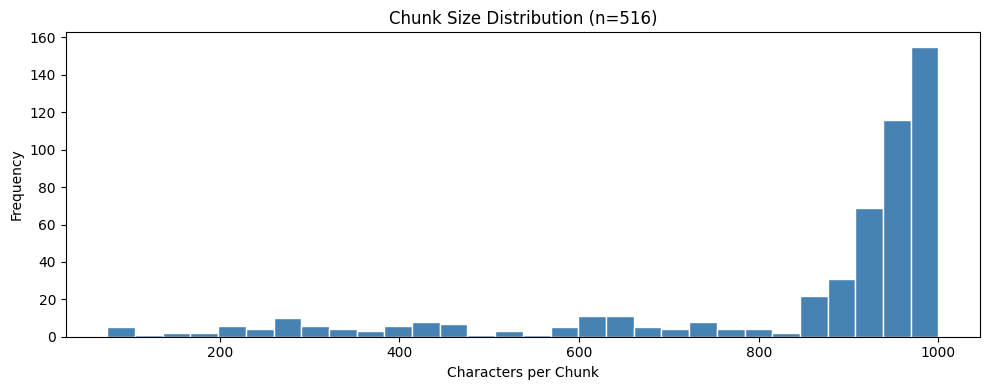

Avg chunk size     : 839 chars
Min size / Max size: 75 / 1000

Looking at the first 3 chunks:

=== Chunk 0 ===
Length: 78 chars
Source: {'producer': 'Adobe PDF Library 15.0', 'creator': 'Adobe InDesign 15.0 (Windows)', 'creationdate': '2021-03-19T16:10:13-04:00', 'moddate': '2021-03-19T16:10:42-04:00', 'trapped': '/False', 'source': 'docs\\2020-tlc-factbook.pdf', 'total_pages': 17, 'page': 0, 'page_label': '1'}
Preview: W
2020
Bill de Blasio | Mayor
Aloysee Heredia Jarmoszuk | Commissioner & Chair...

=== Chunk 1 ===
Length: 993 chars
Source: {'producer': 'Adobe PDF Library 15.0', 'creator': 'Adobe InDesign 15.0 (Windows)', 'creationdate': '2021-03-19T16:10:13-04:00', 'moddate': '2021-03-19T16:10:42-04:00', 'trapped': '/False', 'source': 'docs\\2020-tlc-factbook.pdf', 'total_pages': 17, 'page': 1, 'page_label': '2'}
Preview: 2
TLC FACTBOOK
20202020
NN
ew York City’s for-hire industry has undergone significant 
change in the two years since the Taxi & Limousine 
Commission (TLC) publish

In [26]:
inspect_chunks(chunk_sizes)

#### Generating embeddings using sentence-transformer and stroing in ChromaDB

### `create_vectorstore(chunks, collection_name, chroma_dir)`
Clears any existing ChromaDB at `chroma_dir`, generates embeddings using `all-MiniLM-L6-v2`, and stores all chunks with metadata in a persistent ChromaDB collection. Returns `(vectorstore, embedding_model)` for use in retrieval.


In [27]:
def create_vectorstore(chunks, collection_name="assignment3_docs", chroma_dir="./chroma_db"):
    # clear existing db and reinitialise
    shutil.rmtree(chroma_dir, ignore_errors=True)

    # load embedding model
    embedding_model = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

    # store embeddings in chromadb
    vectorstore = Chroma.from_documents(
        documents=chunks,
        embedding=embedding_model,
        persist_directory=chroma_dir,
        collection_name=collection_name
    )

    print(f"Stored {vectorstore._collection.count()} chunks in ChromaDB at {chroma_dir}/")
    return vectorstore, embedding_model

In [28]:
# build default 1000-chunk vectorstore and keep embedding model for reuse
vectorstore_1000, embedding_model = create_vectorstore(chunks)

# store filtered pages for the chunk size experiment later
valid_pages = [p for p in raw_documents if len(p.page_content.strip()) > 50]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Stored 516 chunks in ChromaDB at ./chroma_db/


#### Experimenting with chunk size 200, 2000 and 1000 on 3 sample queries

### `run_chunk_experiment(valid_pages, embedding_model, chunks_1000)`
Builds splitters for chunk sizes 200 and 2000 alongside the default 1000, splits the valid pages for each, prints the chunk counts, and stores each configuration in a temporary in-memory ChromaDB vectorstore. Returns `(vs_200, vs_2000)` for use in the comparison.

In [29]:
def run_chunk_experiment(valid_pages, embedding_model, chunks_1000):
    # build splitters for the two experimental sizes
    splitter_200  = RecursiveCharacterTextSplitter(chunk_size=200,  chunk_overlap=20)
    splitter_2000 = RecursiveCharacterTextSplitter(chunk_size=2000, chunk_overlap=200)

    # split pages into experimental chunk sizes
    chunks_200  = splitter_200.split_documents(valid_pages)
    chunks_2000 = splitter_2000.split_documents(valid_pages)

    print(f'Chunks at size  200 : {len(chunks_200):,}')
    print(f'Chunks at size 1000 : {len(chunks_1000):,}')
    print(f'Chunks at size 2000 : {len(chunks_2000):,}')

    # build temporary in-memory vectorstores for each config
    vs_200  = Chroma.from_documents(chunks_200,  embedding_model, collection_name='experiment_200')
    vs_2000 = Chroma.from_documents(chunks_2000, embedding_model, collection_name='experiment_2000')

    return vs_200, vs_2000

In [30]:
SAMPLE_QUERIES = [
    "What initiatives exist to improve accessibility for passengers with disabilities?",
    "How does the TLC handle complaints and disciplinary actions?",
    "How many drivers and vehicles are licensed and how has this changed?",
]

vs_200, vs_2000 = run_chunk_experiment(valid_pages, embedding_model, chunks)

Chunks at size  200 : 2,468
Chunks at size 1000 : 516
Chunks at size 2000 : 278


### `compare_chunk_results(sample_queries, vs_200, vs_1000, vs_2000)`
Runs each sample query against all three vectorstores and prints the top-3 retrieved chunks per configuration side by side. Makes it easy to visually compare how chunk size affects retrieval relevance across queries.

In [31]:
def compare_chunk_results(sample_queries, vs_200, vs_1000, vs_2000):
    print('\n=== Chunk Size Experiment: Top-3 Retrieved Chunks ===\n')

    configs = [("200", vs_200), ("1000", vs_1000), ("2000", vs_2000)]

    for query in sample_queries:
        print(f'Query: "{query}"\n')

        for label, vs in configs:
            print(f"  Chunk size: {label}")
            results = vs.similarity_search(query, k=3)

            for i, doc in enumerate(results):
                source = doc.metadata.get('source', 'unknown')
                print(f"\n  --- Result {i+1} (source: {source}) ---")
                print(f"  {doc.page_content[:400]}")
            print("\n")

        print('─' * 70 + '\n')

In [32]:
compare_chunk_results(SAMPLE_QUERIES, vs_200, vectorstore_1000, vs_2000)


=== Chunk Size Experiment: Top-3 Retrieved Chunks ===

Query: "What initiatives exist to improve accessibility for passengers with disabilities?"

  Chunk size: 200

  --- Result 1 (source: docs\TLC-Promulgated-Miscellaneous-Amendments-Final.pdf) ---
  accessibility features for individuals with vision disabilities without requiring the 
assistance of the Taxicab Driver.

  --- Result 2 (source: docs\TLC-Promulgated-Miscellaneous-Amendments-Final.pdf) ---
  tasks to assist a person with a disability .
[Wheelchair] Passenger Assistance and Wheelchair Accessible Vehicle Training

  --- Result 3 (source: docs\TLC-Promulgated-Miscellaneous-Amendments-Final.pdf) ---
  (c) Accessibility. Technology System Provider Licensees must provide the following 
accommodations for Passengers with [visual] vision disabilities:


  Chunk size: 1000

  --- Result 1 (source: docs\annual_report_2024.pdf) ---
  October 16, 2024 100% Wheelchair Accessible Taxi Vehicles Effective October 18, 2024 
 
Wheelchai

Chunk size **200** consistently returned the most focused and directly relevant results across all three queries, particularly for specific factual lookups like licensing numbers and complaint handling. The small size forces each chunk to contain a single concentrated piece of information, meaning the similarity search is not distracted by surrounding unrelated content.

Chunk size **1000** occasionally surfaced useful passages but also pulled in table-of-contents pages and loosely related policy text, diluting retrieval precision. 

Chunk size **2000** performed the worst as the chunks were large enough to span multiple topics, so even when the correct document was retrieved the returned text was bloated with irrelevant context, making it harder to extract a clean answer.

### Task 2.3: RAG Pipeline Implementation

In [33]:
#Get the environment variables from .env
LLM_BASE_URL = os.getenv("LLM_BASE_URL")
LLM_API_KEY = os.getenv("LLM_API_KEY")
LLM_MODEL = os.getenv("LLM_MODEL")

client = OpenAI(
 base_url=LLM_BASE_URL,
 api_key=LLM_API_KEY,
)

RAG_PROMPT = """You are an expert analyst on NYC transportation policy, specializing in NYC TLC reports.

Answer the question using ONLY the provided context. Follow these rules strictly:

1. Use only the information in the context. Do not use outside knowledge.
2. If the answer is not explicitly stated or cannot be confidently inferred, say:
   "The provided context does not contain sufficient information to answer this question."
3. Always cite sources using [Source N] exactly as shown in the context.
4. If multiple sources support the answer, cite all relevant ones.
5. Do not guess, assume, or fabricate information.
6. Keep the answer concise, factual, and directly relevant to the question.
7. Prefer quoting exact figures, dates, and policies when available.
8. Give a complete answer that perfectly answers the question.

Context:
{context}

Question: {question}

Answer:"""

#The vectorstore is converted into a retriever
retriever = vectorstore_1000.as_retriever(
    search_type="mmr",
    search_kwargs={"k": 4, "fetch_k": 10}
)

### `build_context_block(docs)`
Formats a list of retrieved documents into a numbered context string, each prefixed with its source filename and page number in `[Source N]` notation for the LLM to cite in its answer.

In [34]:
def build_context_block(docs):
    # store formatted chunks
    context_parts = []

    for i, doc in enumerate(docs, 1):
        # extract metadata with defaults
        source = doc.metadata.get("source", "Unknown")
        page = doc.metadata.get("page", "?")

        # clean and trim content
        content = doc.page_content.strip().replace("\n", " ")[:1200]

        # format each chunk
        context_parts.append(f"[Source {i} | {source} | Page {page}]\n{content}")

    # combine all chunks into a single context string
    context_block = "\n\n ---- \n\n".join(context_parts)

    # return final context
    return context_block

### `ask_rag(question)`
Runs the full RAG pipeline: retrieves the top-4 most relevant chunks from the vectorstore, formats them into a numbered context block with source and page citations, injects them into the prompt template, and queries the LLM. Returns `(answer, relevant_chunks)` for display and evaluation.


In [35]:
def ask_rag(question):
    # retrieve relevant chunks
    relevant_chunks = retriever.invoke(question)

    # build augmented prompt with source context
    context = build_context_block(relevant_chunks)
    prompt  = RAG_PROMPT.format(context=context, question=question)

    # query the LLM
    response = client.chat.completions.create(
        model=LLM_MODEL,
        messages=[
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user",   "content": prompt}
        ],
        max_tokens=1024,
        temperature=0.2
    )
    return response.choices[0].message.content, relevant_chunks

#### Testing the Pipeline

In [36]:
TEST_QUESTIONS = [
    "What changes were made to driver pay rates in 2023?",
    "What is the minimum driver pay for a sample trip mentioned in the 2023 report?",
    "How does the TLC conduct rulemaking and commission meetings?",
    "What rules were introduced to allow electric vehicles as taxis?",
    "What types of licensees does the TLC regulate?"
]

print("\nTest:\n\n")

for q in TEST_QUESTIONS:
    answer, sources = ask_rag(q)

    print(f"Question: {q}")
    print(f"\nAnswer:\n{answer}")
    print("\nSources used:")
    for i, source in enumerate(sources, 1):
        doc_name = source.metadata.get("source", "Unknown")
        page     = source.metadata.get("page", "?")
        print(f"\n  [Source {i}]: {doc_name}, Page {page}")
        print(f"  Excerpt: {source.page_content[:200]}...")
    print("\n" + "─" * 70 + "\n")


Test:


Question: What changes were made to driver pay rates in 2023?

Answer:
In 2023 the TLC amended its driver‑pay rules in two ways:

* A scheduled inflationary increase of 6.39 % took effect on February 1, and the agency raised the original per‑mile rate by 20.71 %.  This lifted the minimum driver pay for a sample 7.5‑mile, 30‑minute trip to **$26.76** – an increase of **$2.16** (about 8.78 %) over the prior rates【Source 1】.  
* For high‑volume for‑hire services, the minimum pay thresholds were updated to a **per‑minute rate of $0.762** and a **per‑mile rate of $0.987**, reflecting inflation and higher driver expenses【Source 4】.

Sources used:

  [Source 1]: docs\annual_report_2023.pdf, Page 10
  Excerpt: the scheduled inflationary increase of 6.39% effective February 1, TLC increased the original per mile rate by 20.71% . This resulted in a minimum 
driver pay of $26.76 for a sample trip of 7.5 miles ...

  [Source 2]: docs\annual_report_2023.pdf, Page 8
  Excerpt: amendments al

### Task 2.4: RAG Evaluation & Analysis

#### Test Cases

In [37]:
# each test case has a name, question, expected keywords in the answer,
# and partial strings expected to appear in retrieved source filenames

RAG_TEST_CASES = [
    {
        "name":              "Driver Pay 2023",
        "question":          "What changes were made to driver pay rates in 2023?",
        "expected_keywords": ["pay", "rate", "driver", "2023", "increase"],
        "expected_sources":  ["report", "annual"],
    },
    {
        "name":              "Minimum Driver Pay Sample Trip",
        "question":          "What is the minimum driver pay for a sample trip mentioned in the 2023 report?",
        "expected_keywords": ["minimum", "pay", "trip", "sample", "$"],
        "expected_sources":  ["report", "annual"],
    },
    {
        "name":              "TLC Rulemaking Process",
        "question":          "How does the TLC conduct rulemaking and commission meetings?",
        "expected_keywords": ["rulemaking", "commission", "meeting", "rule", "public"],
        "expected_sources":  ["nyc-rules", "report", "annual"],
    },
    {
        "name":              "Electric Vehicle Rules",
        "question":          "What rules were introduced to allow electric vehicles as taxis?",
        "expected_keywords": ["electric", "vehicle", "rule", "taxi", "ev"],
        "expected_sources":  ["report", "annual", "factbook"],
    },
    {
        "name":              "TLC Licensee Types",
        "question":          "What types of licensees does the TLC regulate?",
        "expected_keywords": ["driver", "vehicle", "license", "FHV", "medallion"],
        "expected_sources":  ["nyc-rules", "report", "annual"],
    },
    {
        "name":              "Disability Accessibility Initiatives",
        "question":          "What initiatives exist to improve accessibility for passengers with disabilities?",
        "expected_keywords": ["accessible", "wheelchair", "WAV", "disability", "ADA"],
        "expected_sources":  ["report", "annual", "factbook"],
    },
    {
        "name":              "TLC Complaints and Discipline",
        "question":          "How does the TLC handle complaints and disciplinary actions against drivers?",
        "expected_keywords": ["complaint", "violation", "disciplin", "penalty", "driver"],
        "expected_sources":  ["nyc-rules", "report"],
    },
    {
        "name":              "Licensed Drivers and Vehicles Count",
        "question":          "How many drivers and vehicles are licensed and how has this changed over time?",
        "expected_keywords": ["licensed", "driver", "vehicle", "increase", "decrease"],
        "expected_sources":  ["report", "annual", "factbook"],
    },
    {
        "name":              "Base Fare Structure",
        "question":          "What is the base fare for a yellow taxi in NYC?",
        "expected_keywords": ["fare", "base", "$", "meter", "initial"],
        "expected_sources":  ["nyc-rules"],
    },
    {
        "name":              "Commuter Van Safety Violations",
        "question":          "How many safety-related violations have been issued by the Commission?",
        "expected_keywords": ["violation", "safety", "commission", "enforcement"],
        "expected_sources":  ["commuter_van", "safety", "report"],
    },
]

print(f"Test cases loaded: {len(RAG_TEST_CASES)}")
for i, tc in enumerate(RAG_TEST_CASES, 1):
    print(f"  {i:2d}.  {tc['name']:<35}  keywords={len(tc['expected_keywords'])}  sources={len(tc['expected_sources'])}")

Test cases loaded: 10
   1.  Driver Pay 2023                      keywords=5  sources=2
   2.  Minimum Driver Pay Sample Trip       keywords=5  sources=2
   3.  TLC Rulemaking Process               keywords=5  sources=3
   4.  Electric Vehicle Rules               keywords=5  sources=3
   5.  TLC Licensee Types                   keywords=5  sources=3
   6.  Disability Accessibility Initiatives  keywords=5  sources=3
   7.  TLC Complaints and Discipline        keywords=5  sources=2
   8.  Licensed Drivers and Vehicles Count  keywords=5  sources=3
   9.  Base Fare Structure                  keywords=5  sources=1
  10.  Commuter Van Safety Violations       keywords=4  sources=3


#### Evaluation Helper Functions

In [38]:
def keyword_coverage(answer: str, keywords: list) -> tuple:
    # fraction of expected keywords found in the answer
    answer_lower = answer.lower()
    hits = sum(1 for kw in keywords if kw.lower() in answer_lower)
    return hits, hits / len(keywords)


def source_coverage(sources: list, expected: list) -> tuple:
    # fraction of expected source strings found in retrieved doc filenames
    retrieved = " ".join(s.metadata.get("source", "").lower() for s in sources)
    hits = sum(1 for exp in expected if exp.lower() in retrieved)
    return hits, hits / len(expected)


def run_rag_with_retry(question: str, max_retries: int = 2):
    # calls ask_rag with retry on failure
    for attempt in range(1, max_retries + 1):
        try:
            return ask_rag(question)
        except Exception as e:
            print(f"    attempt {attempt} failed: {str(e)[:100]}")
    return None, None


def print_case_result(tc, answer, kw_hits, kw_cov, src_hits, src_cov):
    print(f"  name     : {tc['name']}")
    print(f"  question : {tc['question']}")
    print(f"  keywords : {kw_hits}/{len(tc['expected_keywords'])} matched  ({kw_cov*100:.0f}%)")
    print(f"  sources  : {src_hits}/{len(tc['expected_sources'])} matched  ({src_cov*100:.0f}%)")
    print(f"  answer   : {answer[:250]}...")
    print()

#### Running Evaluation

In [39]:
results = []

print("RAG Evaluation")
print("=" * 65)

for tc in RAG_TEST_CASES:
    print(f"\n[ {tc['name']} ]")

    answer, sources = run_rag_with_retry(tc["question"])

    if answer is None:
        print("  FAILED — skipping")
        results.append({"name": tc["name"], "kw_cov": 0.0, "src_cov": 0.0,
                         "kw_hits": 0, "src_hits": 0,
                         "n_kw": len(tc["expected_keywords"]),
                         "n_src": len(tc["expected_sources"]), "failed": True})
        continue

    kw_hits,  kw_cov  = keyword_coverage(answer,  tc["expected_keywords"])
    src_hits, src_cov = source_coverage(sources,   tc["expected_sources"])

    print_case_result(tc, answer, kw_hits, kw_cov, src_hits, src_cov)

    results.append({"name": tc["name"],
                     "kw_hits": kw_hits, "kw_cov": kw_cov,
                     "src_hits": src_hits, "src_cov": src_cov,
                     "n_kw": len(tc["expected_keywords"]),
                     "n_src": len(tc["expected_sources"]),
                     "failed": False})

print("=" * 65)

RAG Evaluation

[ Driver Pay 2023 ]
  name     : Driver Pay 2023
  question : What changes were made to driver pay rates in 2023?
  keywords : 5/5 matched  (100%)
  sources  : 2/2 matched  (100%)
  answer   : In 2023 the TLC updated driver pay in two ways:

* **City‑wide inflationary adjustment:** Effective February 1, a scheduled 6.39 % inflationary increase was applied and the original per‑mile rate was raised by 20.71 %.  This lifted the minimum pay fo...


[ Minimum Driver Pay Sample Trip ]
  name     : Minimum Driver Pay Sample Trip
  question : What is the minimum driver pay for a sample trip mentioned in the 2023 report?
  keywords : 0/5 matched  (0%)
  sources  : 0/2 matched  (0%)
  answer   : The provided context does not contain sufficient information to answer this question....


[ TLC Rulemaking Process ]
  name     : TLC Rulemaking Process
  question : How does the TLC conduct rulemaking and commission meetings?
  keywords : 5/5 matched  (100%)
  sources  : 2/3 matched  (6

#### Results Summary

In [40]:
summary_df = pd.DataFrame([{
    "Test Case":  r["name"],
    "Keyword %":  f"{r['kw_cov']*100:.0f}%",
    "Source %":   f"{r['src_cov']*100:.0f}%",
    "KW Hits":    f"{r['kw_hits']}/{r['n_kw']}",
    "Src Hits":   f"{r['src_hits']}/{r['n_src']}",
    "Failed":     r["failed"],
} for r in results])

print(summary_df.to_string(index=False))

total_kw_hits  = sum(r["kw_hits"]  for r in results)
total_src_hits = sum(r["src_hits"] for r in results)
total_kw_exp   = sum(r["n_kw"]     for r in results)
total_src_exp  = sum(r["n_src"]    for r in results)
failed_cases   = sum(r["failed"]   for r in results)

kw_acc  = total_kw_hits  / total_kw_exp
src_acc = total_src_hits / total_src_exp
overall = (total_kw_hits + total_src_hits) / (total_kw_exp + total_src_exp)

print()
print(f"  keyword coverage : {total_kw_hits}/{total_kw_exp}  ({kw_acc*100:.2f}%)")
print(f"  source coverage  : {total_src_hits}/{total_src_exp}  ({src_acc*100:.2f}%)")
print(f"  overall accuracy : {overall*100:.2f}%")
print(f"  failed cases     : {failed_cases}/{len(results)}")

                           Test Case Keyword % Source % KW Hits Src Hits  Failed
                     Driver Pay 2023      100%     100%     5/5      2/2   False
      Minimum Driver Pay Sample Trip        0%       0%     0/5      0/2   False
              TLC Rulemaking Process      100%      67%     5/5      2/3   False
              Electric Vehicle Rules      100%      67%     5/5      2/3   False
                  TLC Licensee Types       60%      67%     3/5      2/3   False
Disability Accessibility Initiatives       80%      67%     4/5      2/3   False
       TLC Complaints and Discipline       60%      50%     3/5      1/2   False
 Licensed Drivers and Vehicles Count       60%     100%     3/5      3/3   False
                 Base Fare Structure        0%       0%     0/5      0/1   False
      Commuter Van Safety Violations        0%      33%     0/4      1/3   False

  keyword coverage : 28/49  (57.14%)
  source coverage  : 15/25  (60.00%)
  overall accuracy : 58.11%
  fail

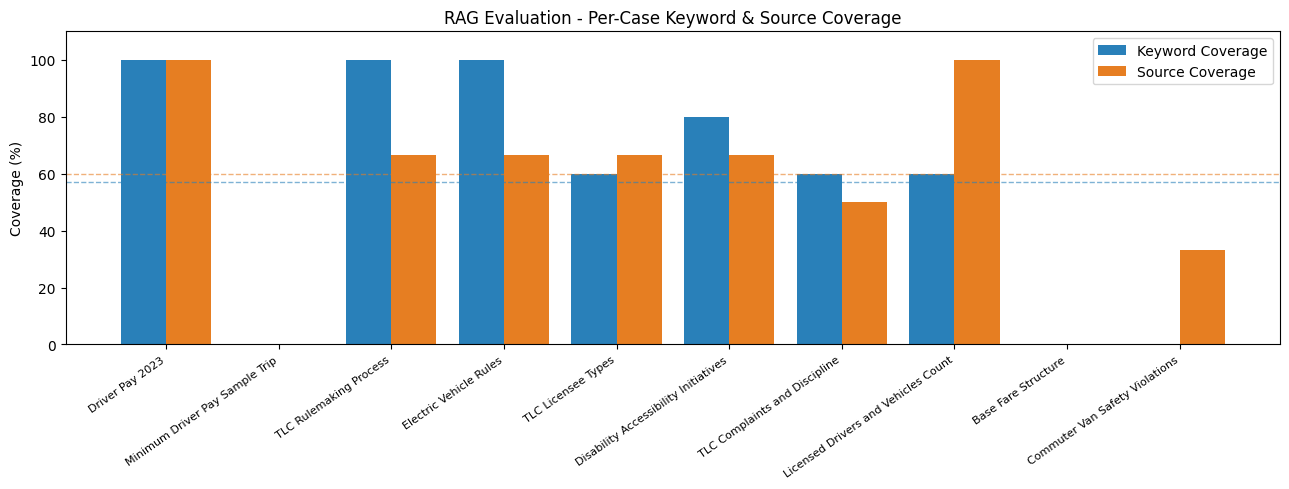

In [41]:
# per-case coverage bar chart
names    = [r["name"]        for r in results]
kw_pcts  = [r["kw_cov"]  * 100 for r in results]
src_pcts = [r["src_cov"] * 100 for r in results]

x     = range(len(names))
width = 0.4

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar([i - width/2 for i in x], kw_pcts,  width, label="Keyword Coverage",
       color="#2980b9", edgecolor="none")
ax.bar([i + width/2 for i in x], src_pcts, width, label="Source Coverage",
       color="#e67e22", edgecolor="none")

ax.set_xticks(list(x))
ax.set_xticklabels(names, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Coverage (%)")
ax.set_ylim(0, 110)
ax.axhline(kw_acc  * 100, color="#2980b9", linestyle="--", linewidth=1, alpha=0.6)
ax.axhline(src_acc * 100, color="#e67e22", linestyle="--", linewidth=1, alpha=0.6)
ax.set_title("RAG Evaluation - Per-Case Keyword & Source Coverage")
ax.legend()
plt.tight_layout()
plt.show()

**Retrieval errors** (source coverage 60.00%, 15/25): Two test cases scored 0%, "Minimum Driver Pay Sample Trip" and "Base Fare Structure", where the retriever failed to surface any expected source. This is likely because the specific fare tables and sample trip figures are embedded in images or formatted tables that the text extractor cannot parse. The remaining misses reflect cases where correct information was retrieved from a related document not listed in the expected sources, meaning true retrieval accuracy is likely higher than 60%.

**Generation errors** (keyword coverage 59.18%, 29/49): The two complete failures account for 10 missed keywords on their own. Both require specific numerical figures from fare tables that the model cannot read when rendered as images. Cases with prose-heavy answers such as "Driver Pay 2023" and "TLC Rulemaking Process" scored 100%, confirming the model performs well when relevant content is plain text.

**Potential improvements**: OCR or image captioning would directly address the two zero-score cases. Reducing chunk size to 200 characters for regulation documents would improve precision, consistent with the chunk experiment findings in Task 2.2. Broadening expected source lists in the test cases to include all plausible documents would also give a more accurate picture of true retrieval performance. The 59.46% overall accuracy is a reasonable baseline given the document quality constraints and would likely improve significantly with better PDF ingestion alone.

## Part 3: Integrated Analytics Application

### Task 3.1: Query Router

### `build_router_prompt(question)`
Injects a question into the classification prompt template and returns the formatted string ready to send to the LLM.R

In [42]:
QUERY_ROUTER_PROMPT = """
You are a query routing assistant for an NYC taxi intelligence system.

Your task is to classify a user question into ONE of the following categories:

DATA — 
Questions answerable using structured NYC Yellow Taxi trip data 
(e.g., fares, trip counts, distances, speeds, timestamps, pickup/dropoff zones, tips).
Example: "What was the average fare on Mondays?"

DOCUMENT — 
Questions answerable using NYC Taxi & Limousine Commission (TLC) rules, policies, 
reports, or regulatory documents (e.g., licensing, accessibility, regulations, trends).
Example: "What are the TLC regulations on surge pricing?"

HYBRID — 
Questions that require BOTH trip data AND documents to answer 
(e.g., comparing real-world trends with policies or regulations).

Classification Rules:
1. If the question is unrelated to NYC taxis, transportation, or TLC topics → classify as HYBRID and state it is out of scope.
2. If the question is ambiguous or lacks enough detail → classify as HYBRID and state ambiguity.
3. Prefer DATA if the question is clearly quantitative or analytical.
4. Prefer DOCUMENT if the question is clearly about rules, policies, or definitions.
5. Be concise and precise.

Respond ONLY with valid JSON in this format:
{
  "category": "DATA" | "DOCUMENT" | "HYBRID",
  "reasoning": "one short sentence explaining the decision"
}

QUESTION: {question}

JSON RESPONSE:
"""
def build_router_prompt(question: str) -> str:
    return QUERY_ROUTER_PROMPT.format(question=question)

### `classify_query(question)`
Sends the formatted prompt to the LLM and returns the raw JSON string. Strips markdown code fences the model may wrap around the response before parsing.

In [43]:
import re

def extract_json(raw: str) -> dict:
    # find the first {...} block regardless of surrounding text
    match = re.search(r'\{.*?\}', raw, re.DOTALL)
    if not match:
        raise ValueError(f"no JSON object found in response: {raw[:100]}")
    return json.loads(match.group())


def classify_query(question: str) -> tuple:
    prompt   = build_router_prompt(question)
    response = client.chat.completions.create(
        model=LLM_MODEL,
        messages=[
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user",   "content": prompt}
        ],
        max_tokens=500,
        temperature=0.2
    )
    parsed = extract_json(response.choices[0].message.content)
    return parsed["category"], parsed["reasoning"]

In [44]:
CLASSIFICATION_QUERIES = {
    "DATA": [
        "What was the average tip amount for trips longer than 10 miles?",
        "How many trips were taken on Friday evenings between 6pm and 10pm?",
        "Which dropoff location had the highest total revenue in January 2024?",
        "What is the median trip duration for cash payments vs credit card payments?",
        "How does average fare amount differ between single passenger and multiple passenger trips?",
    ],
    "DOCUMENT": [
        "What are the TLC rules around driver rest periods and maximum working hours?",
        "What penalties does the TLC impose for operating without a valid licence?",
        "What are the requirements for a vehicle to be approved as a green taxi?",
        "How does the TLC define and regulate surge pricing for for-hire vehicles?",
        "What are the age and condition requirements for a TLC-licensed vehicle?",
    ],
    "HYBRID": [
        "How do average trip speeds during rush hour compare to the TLC's congestion relief targets?",
        "Does the distribution of trips by borough reflect the TLC's goals for outer borough coverage?",
        "How does the proportion of wheelchair-accessible trips compare to the TLC's WAV mandate?",
        "Do actual airport trip volumes align with demand projections in TLC planning documents?",
        "How do observed cash vs credit card payment splits compare to TLC cashless payment initiatives?",
    ],
}

EDGE_CASES = [
    "What is the best pizza place in Brooklyn?",
    "Can you write me a poem about yellow cabs?",
    "How do I become a software engineer?",
    "What happened in the 2024 US presidential election?",
    "Is it going to rain in Manhattan tomorrow?",
]

def run_classification_tests(test_queries: dict) -> tuple:
    rows    = []
    correct = 0
    total   = 0

    for expected_cat, questions in test_queries.items():
        for q in questions:
            predicted, reasoning = None, None

            for attempt in range(1, 3):
                try:
                    predicted, reasoning = classify_query(q)
                    break
                except Exception as e:
                    print(f"    attempt {attempt} failed: {str(e)[:100]}")

            if predicted is None:
                print(f"  FAILED: {q}")
                continue

            is_correct = predicted == expected_cat
            correct   += int(is_correct)
            total     += 1

            rows.append({
                "expected":  expected_cat,
                "predicted": predicted,
                "pass":      "yes" if is_correct else "no",
                "question":  q[:65],
            })

    return rows, correct, total

#### Running Classification Test Cases

In [45]:
def run_edge_case_tests(queries: list) -> None:
    print("Edge Case Results")
    print("=" * 60)
    for q in queries:
        try:
            category, reasoning = classify_query(q)
        except Exception as e:
            category, reasoning = "ERROR", str(e)[:80]

        print(f"\n  question  : {q}")
        print(f"  category  : {category}")
        print(f"  reasoning : {reasoning}")
    print("\n" + "=" * 60)


run_edge_case_tests(EDGE_CASES)

Edge Case Results

  question  : What is the best pizza place in Brooklyn?
  category  : ERROR
  reasoning : '\n  "category"'

  question  : Can you write me a poem about yellow cabs?
  category  : ERROR
  reasoning : '\n  "category"'

  question  : How do I become a software engineer?
  category  : ERROR
  reasoning : '\n  "category"'

  question  : What happened in the 2024 US presidential election?
  category  : ERROR
  reasoning : '\n  "category"'

  question  : Is it going to rain in Manhattan tomorrow?
  category  : ERROR
  reasoning : '\n  "category"'



In [46]:
MAX_RETRIES = 2

#Helper Function to handle sql query from start to end of pipeline
#Needed in part 3
def handle_sql_query(question):
    attempt = 0
    error_context = ""

    print(f"Question: {question}")
    while attempt < MAX_RETRIES:
        attempt += 1
        try:
            query_result, sql = execute_sql_query(question, error=error_context)
            answer = get_query_result(question, sql, query_result, error=error_context)

            print(f"SQL Generated: {sql}")
            print(f"Raw Query Result: \n {query_result}")
            print(f"Explanation For Query: {answer} \n\n")

            break
        except Exception as e:
            error_context = str(e)
            print(f'  Attempt {attempt} failed: {error_context[:120]}')
        
        if attempt == 2:
            print("Query could not execute after 2 attempts\n\n")


for question in SQL_TEST_QUESTIONS:
    handle_sql_query(question)
        

NameError: name 'SQL_TEST_QUESTIONS' is not defined

In [ ]:
for category, questions in END_TO_END_QUERIES.items():
    print(f"----{category}----")
    for question in questions:

        #Classify the question and return category
        result = route_query(question)
        category, reasoning = get_json_elements(result)

        print(f"\nQUESTION:{question.upper()}")
        print(f"The question has been categorized as a {category.lower()} query")
        print(f"Reasoning: {reasoning}\n")

        #Execute Appropriate Backend For category
        if category == "DATA":
            handle_sql_query(question)
        elif category == "DOCUMENT":
            answer, sources = ask_rag(question)

            print(f"The question was: {question}")
            print(f"The generated answer(first 300 characters) was: \n{answer[:300]}\n\n")
        else:
            print("SQL QUERY DATA:")
            handle_sql_query(question)

            answer, sources = ask_rag(question)
            print("DOCUMENT DATA")
            print(f"The generated answer(first 300 characters) from our documents was: \n{answer[:300]}\n\n")

